# Day 5 - Baseline Model Training

## Goal
Train the first machine learning models to predict Bitcoin closing prices.

### Models
- Linear Regression (baseline model)
- Random Forest Regressor (advanced baseline)

### Evaluation Metrics
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

The objective is to compare both models and select the better performer.

In [96]:
df = pd.read_csv("processed_btc_data.csv")

df.head()

,Date,Close,High,Low,Open,Volume,MA7,MA30,Lag1,Lag2,Lag3,Returns,RSI
0,2018-01-30,10106.299805,11307.200195,10036.200195,11306.799805,8637859840,11202.843052,13181.040039,11296.400391,11786.299805,11440.700195,-0.105352,40.137091
1,2018-01-31,10221.099609,10381.599609,9777.419922,10108.200195,8041160192,11040.228655,13066.503353,10106.299805,11296.400391,11786.299805,0.011359,42.917380
2,2018-02-01,9170.540039,10288.799805,8812.280273,10237.299805,9959400448,10741.820033,12872.784701,10221.099609,10106.299805,11296.400391,-0.102783,34.828472
3,2018-02-02,8830.750000,9142.280273,7796.490234,9142.280273,12726899712,10407.441406,12660.443034,9170.540039,10221.099609,10106.299805,-0.037052,32.204720
4,2018-02-03,9174.910156,9430.750000,8251.629883,8852.120117,7263790080,10083.757115,12446.300033,8830.750000,9170.540039,10221.099609,0.038973,22.831301


In [97]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt

## Load Processed Dataset

This dataset already contains the features created during preprocessing and feature engineering.

In [98]:
df = pd.read_csv("processed_btc_data.csv")

df.head()

,Date,Close,High,Low,Open,Volume,MA7,MA30,Lag1,Lag2,Lag3,Returns,RSI
0,2018-01-30,10106.299805,11307.200195,10036.200195,11306.799805,8637859840,11202.843052,13181.040039,11296.400391,11786.299805,11440.700195,-0.105352,40.137091
1,2018-01-31,10221.099609,10381.599609,9777.419922,10108.200195,8041160192,11040.228655,13066.503353,10106.299805,11296.400391,11786.299805,0.011359,42.917380
2,2018-02-01,9170.540039,10288.799805,8812.280273,10237.299805,9959400448,10741.820033,12872.784701,10221.099609,10106.299805,11296.400391,-0.102783,34.828472
3,2018-02-02,8830.750000,9142.280273,7796.490234,9142.280273,12726899712,10407.441406,12660.443034,9170.540039,10221.099609,10106.299805,-0.037052,32.204720
4,2018-02-03,9174.910156,9430.750000,8251.629883,8852.120117,7263790080,10083.757115,12446.300033,8830.750000,9170.540039,10221.099609,0.038973,22.831301


In [99]:
print(df.shape)

df.columns

(2893, 13)


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA7', 'MA30', 'Lag1',
       'Lag2', 'Lag3', 'Returns', 'RSI'],
      dtype='object')

## Define Features and Target

Features are used as inputs.
Close price will be our prediction target.

In [100]:
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "MA7",
    "MA30",
    "Lag1",
    "Lag2",
    "Lag3",
    "Returns",
    "RSI"
]

target = "Close"

X = df[features]

y = df[target]

## Train-Test Split

Because this is time-series data, shuffle=False is used to preserve chronological order.

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [102]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2314, 11)
X_test: (579, 11)
y_train: (2314,)
y_test: (579,)


## Linear Regression Model

Linear Regression is used as the baseline model.

In [103]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [104]:
lr_preds = lr.predict(X_test)

In [105]:
lr_mae = mean_absolute_error(
    y_test,
    lr_preds
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_preds
    )
)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression MAE: 603.2426714823193
Linear Regression RMSE: 802.6996447503212


## Random Forest Regressor

Random Forest can capture non-linear relationships and often performs better on other  datasets.

In [106]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [107]:
rf_preds = rf.predict(X_test)

In [108]:
rf_mae = mean_absolute_error(
    y_test,
    rf_preds
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_preds
    )
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 21463.83872200183
Random Forest RMSE: 26838.919224828078


## Model Comparison

Compare model performance using MAE and RMSE.
Lower values indicate better performance.

In [109]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ]
})

results

,Model,MAE,RMSE
0,Linear Regression,603.242671,802.699645
1,Random Forest,21463.838722,26838.919225


## Prediction Visualization

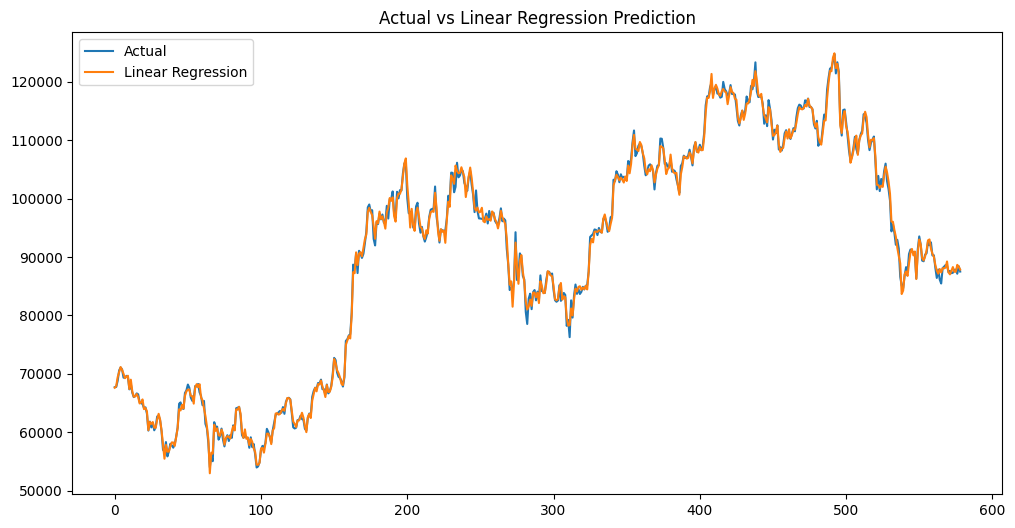

In [110]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_preds,
    label="Linear Regression"
)

plt.legend()

plt.title("Actual vs Linear Regression Prediction")

plt.show()

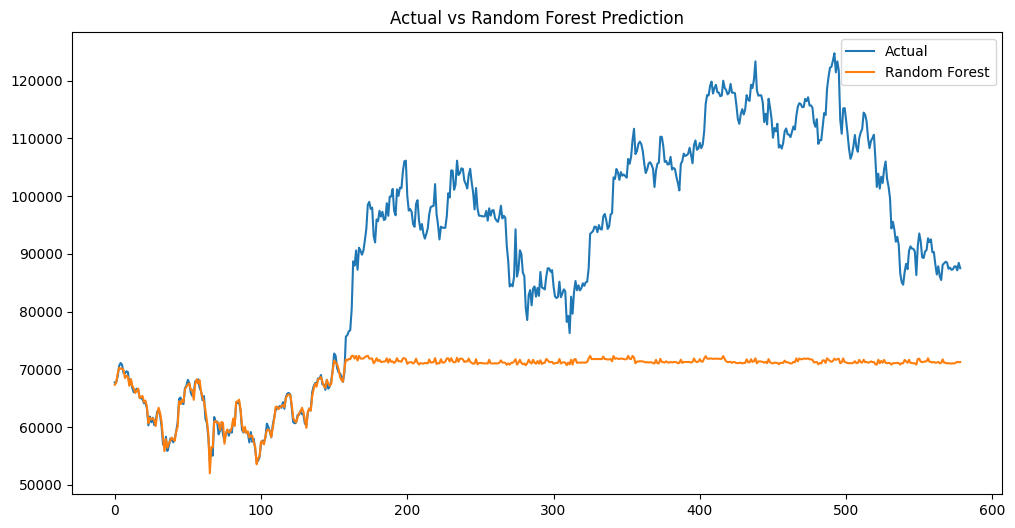

In [111]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    rf_preds,
    label="Random Forest"
)

plt.legend()

plt.title("Actual vs Random Forest Prediction")

plt.show()

# Observations

Linear Regression:
- MAE = 603.242671
- RMSE =802.699645

Random Forest:
- MAE = 21463.83872200183
- RMSE = 26838.919224828078

Selected Model:
Linear Regression

Reason:
The selected model achieved lower prediction error and better tracked the actual Bitcoin price trend.